# One-at-a-time incremental stitching

This notebook stitches a set of images incrementally, one image at a time (lexicographic order). It detects features once for all images, then merges images sequentially by matching the next image to the cumulative feature bank, estimating a homography, warping and blending, and merging feature sets while deduplicating matched common features. This avoids re-running feature detection on already-merged content. Intermediate visualizations are shown at each step.

Notes:
- Images are ordered by filename (lexicographically).
- Features are detected once per image up front.
- At each step, we match current image descriptors to the combined feature bank, estimate Homography (RANSAC), warp and blend to the current mosaic, and merge features (transforming them into the mosaic base frame, deduplicating within a pixel threshold so matched common features are counted only once).
- Resizing keeps the spirit of the tutorial (medium/low style) but NEVER upscales. Small images like 640x480 are kept at native resolution.
- Visualizations: keypoints (green dots), matches (lines), and the growing mosaic with cumulative keypoints.


In [8]:
import os
from pathlib import Path
from typing import List, Tuple, Dict
import time
import re

import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

from stitching.feature_detector import FeatureDetector
from stitching.feature_matcher import FeatureMatcher
from stitching.camera_estimator import CameraEstimator
from stitching.camera_adjuster import CameraAdjuster
from stitching.camera_wave_corrector import WaveCorrector
from stitching.warper import Warper
from stitching.seam_finder import SeamFinder
from stitching.exposure_error_compensator import ExposureErrorCompensator
from stitching.blender import Blender
from stitching.subsetter import Subsetter

np.set_printoptions(suppress=True, linewidth=140)

def plot_image(img, figsize=(6,6), title=None):
    fig, ax = plt.subplots(figsize=figsize)
    if img.ndim == 2:
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    if title:
        ax.set_title(title)
    ax.axis('off')
    plt.show()

def plot_images(imgs, titles=None, figsize=(16,6)):
    n = len(imgs)
    fig, axs = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axs = [axs]
    for i, img in enumerate(imgs):
        if img.ndim == 2:
            axs[i].imshow(img, cmap='gray')
        else:
            axs[i].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        if titles is not None:
            axs[i].set_title(titles[i])
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

## Configuration and ESP-based image grouping

In [9]:
# Directory of input images
IMAGE_DIR = "final/data/calibration_run"  # change if needed
EXTS = (".jpg", ".jpeg", ".png", ".bmp")

# Optionally override with explicit list
IMAGE_PATHS: List[str] = []

def list_images_sorted(image_dir: str) -> List[str]:
    files = [str(Path(image_dir) / f) for f in os.listdir(image_dir)
             if f.lower().endswith(EXTS) and not f.startswith('.')]
    files.sort()
    return files

def extract_esp_id(filename: str) -> str:
    """Extract ESP ID from filename like 'esp_1_timestamp.jpg' -> 'esp_1'"""
    basename = Path(filename).stem
    # Look for pattern like esp_X where X is a number
    match = re.match(r'(esp_\d+)', basename.lower())
    if match:
        return match.group(1)
    # Fallback: use first part before underscore if it contains 'esp'
    parts = basename.lower().split('_')
    for i, part in enumerate(parts):
        if 'esp' in part and i < len(parts) - 1:
            return f"{part}_{parts[i+1]}"
    # If no ESP pattern found, group by first part of filename
    return parts[0] if parts else "unknown"

def group_images_by_esp(image_paths: List[str]) -> Dict[str, List[str]]:
    """Group image paths by ESP device ID"""
    groups = {}
    for path in image_paths:
        esp_id = extract_esp_id(Path(path).name)
        if esp_id not in groups:
            groups[esp_id] = []
        groups[esp_id].append(path)
    return groups

if IMAGE_PATHS:
    imgs_list = [str(Path(p)) for p in IMAGE_PATHS]
else:
    imgs_list = list_images_sorted(IMAGE_DIR)

print(f"Found {len(imgs_list)} images")

# Group by ESP
esp_groups = group_images_by_esp(imgs_list)
print(f"\nGrouped into {len(esp_groups)} ESP devices:")
for esp_id, paths in esp_groups.items():
    print(f"  {esp_id}: {len(paths)} images")
    for i, path in enumerate(paths[:3]):  # Show first 3
        print(f"    • {Path(path).name}")
    if len(paths) > 3:
        print(f"    ... and {len(paths)-3} more")

assert len(esp_groups) >= 2, "Need at least two ESP groups to create final panorama"

Found 42 images

Grouped into 4 ESP devices:
  esp_1: 12 images
    • esp_1_1757157562687.jpg
    • esp_1_1757157562915.jpg
    • esp_1_1757157563438.jpg
    ... and 9 more
  esp_2: 12 images
    • esp_2_1757157562695.jpg
    • esp_2_1757157562819.jpg
    • esp_2_1757157563430.jpg
    ... and 9 more
  esp_3: 7 images
    • esp_3_1757157562669.jpg
    • esp_3_1757157562983.jpg
    • esp_3_1757157563605.jpg
    ... and 4 more
  esp_4: 11 images
    • esp_4_1757157562586.jpg
    • esp_4_1757157563076.jpg
    • esp_4_1757157563116.jpg
    ... and 8 more


## Stitching parameters

In [10]:
WORK_MPIX = 0.6  # Resolution for intra-ESP stitching
HIGH_MPIX = 1.2  # Higher resolution for final inter-ESP stitching
DETECTOR = "orb"   # orb | brisk | akaze | sift
N_FEATURES_INTRA = 3000  # Features for intra-ESP (high overlap)
N_FEATURES_INTER = 8000  # More features for inter-ESP (lower overlap)

def resize_to_megapix(img: np.ndarray, target_mpix: float, allow_upscale: bool = False) -> np.ndarray:
    if target_mpix is None or target_mpix <= 0:
        return img
    h, w = img.shape[:2]
    cur_mpix = (w * h) / 1e6
    if cur_mpix <= 0:
        return img
    scale = np.sqrt(target_mpix / cur_mpix)
    if scale >= 1.0 and not allow_upscale:
        return img
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    interp = cv.INTER_AREA if scale < 1.0 else cv.INTER_LINEAR
    return cv.resize(img, (new_w, new_h), interpolation=interp)

## Stage 1: Spherical stitching within each ESP group


STAGE 1: Stitching ESP group 'esp_1' (12 images)
Image sizes: ['800x600', '800x600', '800x600']
Detecting features...
Features detected: [2157, 2002, 2242, 1254, 2059, 2472, 2487, 2501, 2528, 2638, 2599, 2453]
Matching features...
Pairwise matches: 130
Estimating cameras...
Adjusting cameras...
Pairwise matches: 130
Estimating cameras...
Adjusting cameras...
Warping images...
Finding seams...
Warping images...
Finding seams...
Compensating exposure...
Compensating exposure...
Blending...
ESP 'esp_1' stitching completed: 805x498
Saved: esp_esp_1_spherical.jpg
Blending...
ESP 'esp_1' stitching completed: 805x498
Saved: esp_esp_1_spherical.jpg


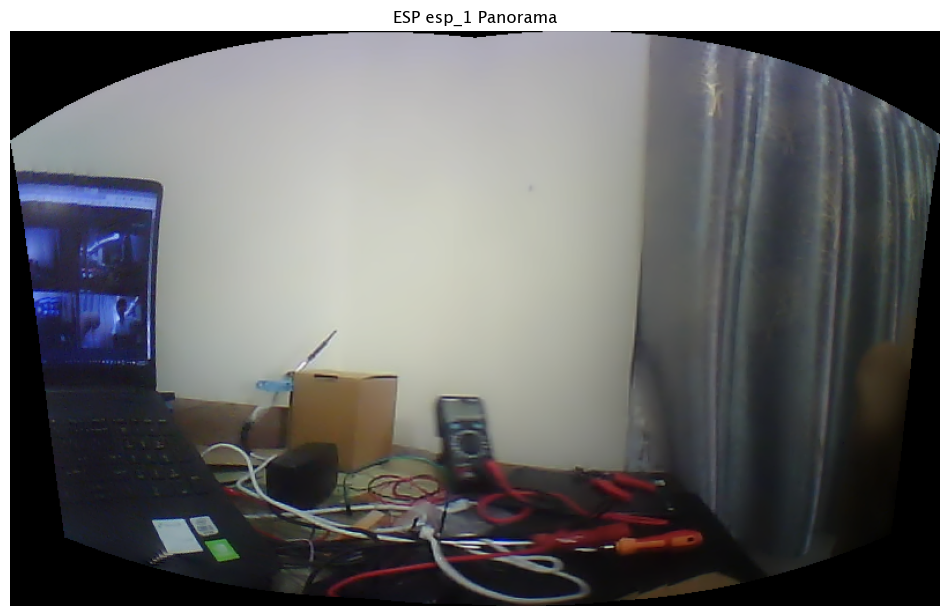


STAGE 1: Stitching ESP group 'esp_2' (12 images)
Image sizes: ['800x600', '800x600', '800x600']
Detecting features...
Features detected: [2797, 2755, 2671, 1873, 2555, 2517, 2440, 2512, 2444, 2551, 2482, 2402]
Matching features...
Features detected: [2797, 2755, 2671, 1873, 2555, 2517, 2440, 2512, 2444, 2551, 2482, 2402]
Matching features...
Pairwise matches: 130
Estimating cameras...
Adjusting cameras...
Pairwise matches: 130
Estimating cameras...
Adjusting cameras...
Warping images...
Finding seams...
Warping images...
Finding seams...
Compensating exposure...
Compensating exposure...
Blending...
ESP 'esp_2' stitching completed: 730x463
Saved: esp_esp_2_spherical.jpg
Blending...
ESP 'esp_2' stitching completed: 730x463
Saved: esp_esp_2_spherical.jpg


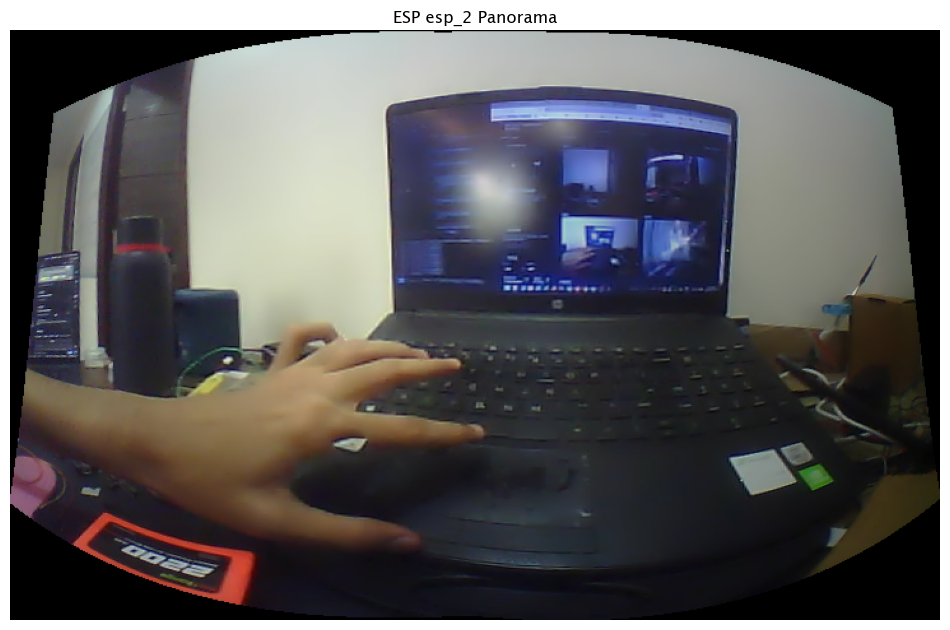


STAGE 1: Stitching ESP group 'esp_3' (7 images)
Image sizes: ['800x600', '800x600', '800x600']
Detecting features...
Features detected: [2885, 2859, 2950, 2715, 2985, 2986, 2991]
Matching features...
Features detected: [2885, 2859, 2950, 2715, 2985, 2986, 2991]
Matching features...
Pairwise matches: 42
Estimating cameras...
Adjusting cameras...
Pairwise matches: 42
Estimating cameras...
Adjusting cameras...
Warping images...
Finding seams...
Compensating exposure...
Blending...
Warping images...
Finding seams...
Compensating exposure...
Blending...
ESP 'esp_3' stitching completed: 481x366
Saved: esp_esp_3_spherical.jpg
ESP 'esp_3' stitching completed: 481x366
Saved: esp_esp_3_spherical.jpg


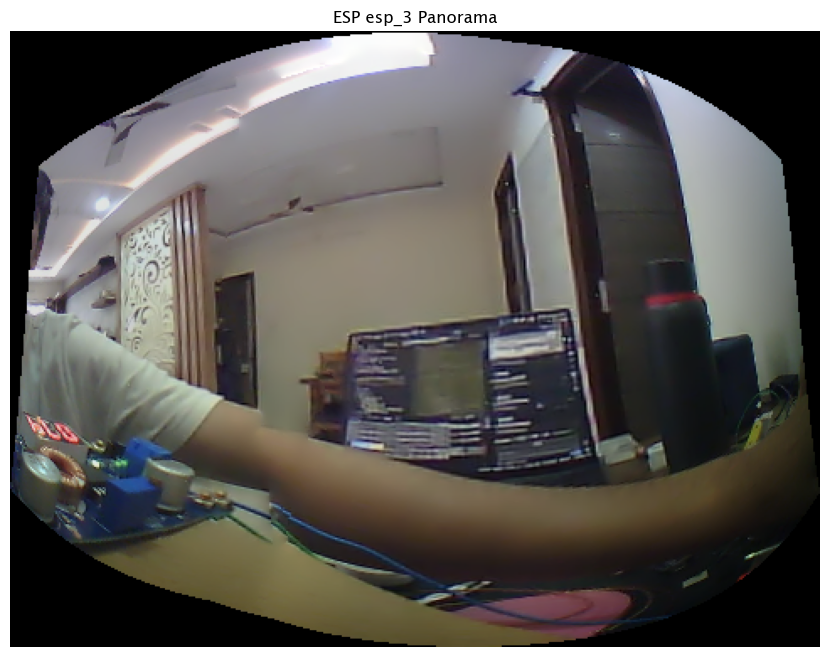


STAGE 1: Stitching ESP group 'esp_4' (11 images)
Image sizes: ['640x480', '640x480', '640x480']
Detecting features...
Features detected: [1981, 1763, 1418, 1628, 1041, 618, 793, 580, 733, 631, 500]
Matching features...
Pairwise matches: 106
Estimating cameras...
Adjusting cameras...
Pairwise matches: 106
Estimating cameras...
Adjusting cameras...
Warping images...
Finding seams...
Warping images...
Finding seams...
Compensating exposure...
Compensating exposure...
Blending...
ESP 'esp_4' stitching completed: 643x411
Saved: esp_esp_4_spherical.jpg
Blending...
ESP 'esp_4' stitching completed: 643x411
Saved: esp_esp_4_spherical.jpg


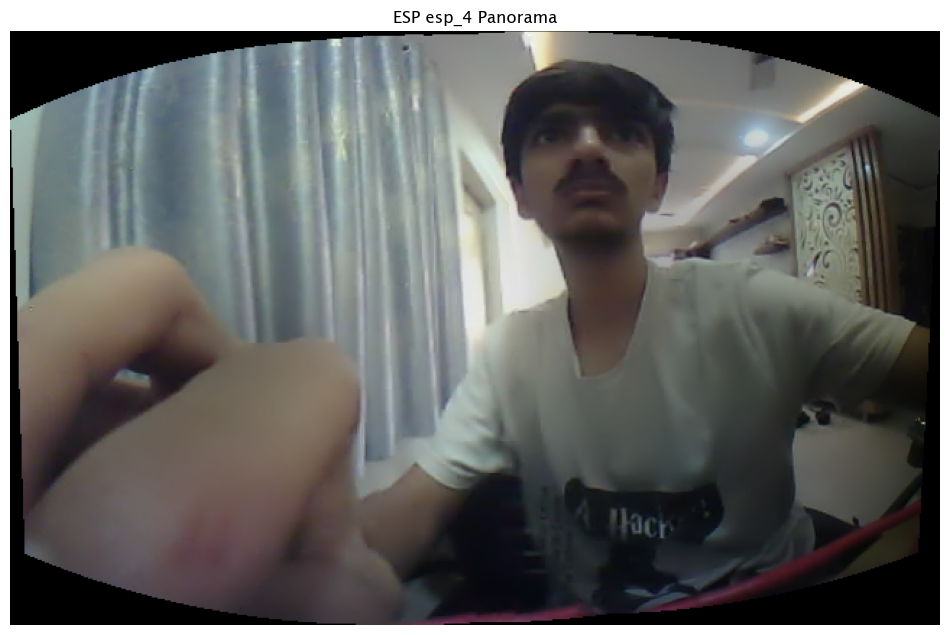


Stage 1 completed: 4 ESP panoramas created


In [11]:
def stitch_esp_group_spherical(image_paths: List[str], esp_id: str, work_mpix: float = 0.6) -> np.ndarray:
    """Stitch images from a single ESP using spherical projection"""
    print(f"\n{'='*60}")
    print(f"STAGE 1: Stitching ESP group '{esp_id}' ({len(image_paths)} images)")
    print(f"{'='*60}")
    
    if len(image_paths) == 1:
        img = cv.imread(image_paths[0], cv.IMREAD_COLOR)
        return resize_to_megapix(img, work_mpix, allow_upscale=False)
    
    # Load and resize images
    imgs = []
    for path in image_paths:
        img = cv.imread(path, cv.IMREAD_COLOR)
        if img is None:
            raise ValueError(f"Failed to read image: {path}")
        imgs.append(resize_to_megapix(img, work_mpix, allow_upscale=False))
    
    print(f"Image sizes: {[f'{img.shape[1]}x{img.shape[0]}' for img in imgs[:3]]}")
    
    try:
        # Use stitching library components
        finder = FeatureDetector(detector=DETECTOR, nfeatures=N_FEATURES_INTRA)
        matcher = FeatureMatcher(matcher_type="homography", range_width=-1)  # Match all pairs
        
        # Detect features
        print("Detecting features...")
        features = [finder.detect_features(img) for img in imgs]
        print(f"Features detected: {[len(f.keypoints) for f in features]}")
        
        # Match features
        print("Matching features...")
        matches = matcher.match_features(features)
        print(f"Pairwise matches: {len([m for m in matches if m.confidence > 0.3])}")
        
        # Keep only well-connected images
        subsetter = Subsetter(confidence_threshold=0.3)
        indices = subsetter.get_indices_to_keep(features, matches)
        
        if len(indices) != len(features):
            print(f"Keeping {len(indices)}/{len(features)} well-connected images")
            imgs = [imgs[i] for i in indices]
            features = [features[i] for i in indices]
            matches = subsetter.subset_matches(matches, indices)
        
        if len(imgs) < 2:
            print("Not enough connected images, returning first image")
            return imgs[0] if imgs else np.zeros((480, 640, 3), dtype=np.uint8)
        
        # Camera estimation
        print("Estimating cameras...")
        estimator = CameraEstimator()
        cameras = estimator.estimate(features, matches)
        
        # Camera adjustment
        print("Adjusting cameras...")
        adjuster = CameraAdjuster(confidence_threshold=0.3)
        try:
            cameras = adjuster.adjust(features, matches, cameras)
        except Exception as e:
            print(f"Camera adjustment failed, trying lower confidence: {e}")
            adjuster = CameraAdjuster(confidence_threshold=0.1)
            cameras = adjuster.adjust(features, matches, cameras)
        
        # Wave correction
        corrector = WaveCorrector()
        cameras = corrector.correct(cameras)
        
        # Warping
        print("Warping images...")
        warper = Warper("spherical")
        warper.set_scale(cameras)
        
        sizes = [(img.shape[1], img.shape[0]) for img in imgs]
        
        # Warp images and masks
        warped_imgs = list(warper.warp_images(imgs, cameras, aspect=1.0))
        warped_masks = list(warper.create_and_warp_masks(sizes, cameras, aspect=1.0))
        corners, sizes_out = warper.warp_rois(sizes, cameras, aspect=1.0)
        
        # Seam finding
        print("Finding seams...")
        seam_finder = SeamFinder()
        seam_masks = seam_finder.find(warped_imgs, corners, warped_masks)
        
        # Exposure compensation
        print("Compensating exposure...")
        compensator = ExposureErrorCompensator()
        compensator.feed(corners, warped_imgs, warped_masks)
        compensated_imgs = [
            compensator.apply(i, corner, img, mask)
            for i, (img, mask, corner) in enumerate(zip(warped_imgs, warped_masks, corners))
        ]
        
        # Blending
        print("Blending...")
        blender = Blender()
        blender.prepare(corners, sizes_out)
        for img, mask, corner in zip(compensated_imgs, seam_masks, corners):
            blender.feed(img, mask, corner)
        
        result, _ = blender.blend()
        
        print(f"ESP '{esp_id}' stitching completed: {result.shape[1]}x{result.shape[0]}")
        
        # Save intermediate result
        out_path = f"esp_{esp_id}_spherical.jpg"
        cv.imwrite(out_path, result)
        print(f"Saved: {out_path}")
        
        return result
        
    except Exception as e:
        print(f"Spherical stitching failed for ESP '{esp_id}': {e}")
        print("Falling back to simple panorama...")
        
        # Fallback: simple homography-based stitching
        if len(imgs) >= 2:
            result = imgs[0]
            for i in range(1, len(imgs)):
                result = simple_stitch_pair(result, imgs[i])
            return result
        return imgs[0] if imgs else np.zeros((480, 640, 3), dtype=np.uint8)

def simple_stitch_pair(img1, img2, detector_type="orb", n_features=2000):
    """Simple homography-based stitching of two images"""
    # Create detector
    if detector_type.lower() == "orb":
        detector = cv.ORB_create(nfeatures=n_features)
        norm = cv.NORM_HAMMING
    elif detector_type.lower() == "sift":
        detector = cv.SIFT_create(nfeatures=n_features)
        norm = cv.NORM_L2
    else:
        detector = cv.ORB_create(nfeatures=n_features)
        norm = cv.NORM_HAMMING
    
    # Detect and match
    kp1, desc1 = detector.detectAndCompute(img1, None)
    kp2, desc2 = detector.detectAndCompute(img2, None)
    
    if desc1 is None or desc2 is None or len(kp1) < 4 or len(kp2) < 4:
        # No features, just concatenate
        return np.hstack([img1, img2])
    
    # Handle UMat objects
    if hasattr(desc1, 'get'):
        desc1 = desc1.get()
    if hasattr(desc2, 'get'):
        desc2 = desc2.get()
    
    # Ensure descriptors are numpy arrays
    if not isinstance(desc1, np.ndarray):
        desc1 = np.array(desc1)
    if not isinstance(desc2, np.ndarray):
        desc2 = np.array(desc2)
    
    if desc1.shape[0] == 0 or desc2.shape[0] == 0:
        return np.hstack([img1, img2])
    
    bf = cv.BFMatcher(norm, crossCheck=False)
    matches = bf.knnMatch(desc1, desc2, k=2)
    
    # Ratio test
    good = []
    for m in matches:
        if len(m) == 2 and m[0].distance < 0.75 * m[1].distance:
            good.append(m[0])
    
    if len(good) < 4:
        return np.hstack([img1, img2])
    
    # Homography
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    
    H, mask = cv.findHomography(dst_pts, src_pts, cv.RANSAC, 5.0)
    if H is None:
        return np.hstack([img1, img2])
    
    # Ensure H is float32
    H = H.astype(np.float32)
    
    # Warp and blend
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    corners2 = np.float32([[0, 0], [w2, 0], [w2, h2], [0, h2]]).reshape(-1, 1, 2)
    corners2_transformed = cv.perspectiveTransform(corners2, H).reshape(-1, 2)
    
    corners1 = np.float32([[0, 0], [w1, 0], [w1, h1], [0, h1]])
    
    all_corners = np.vstack([corners1, corners2_transformed])
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel())
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel())
    
    # Ensure translation values are valid
    translation = [float(-x_min), float(-y_min)]
    H_translate = np.array([[1.0, 0.0, translation[0]], 
                           [0.0, 1.0, translation[1]], 
                           [0.0, 0.0, 1.0]], dtype=np.float32)
    
    result_width = int(x_max - x_min)
    result_height = int(y_max - y_min)
    
    # Ensure dimensions are positive
    if result_width <= 0 or result_height <= 0:
        return np.hstack([img1, img2])
    
    # Limit maximum size to prevent memory issues
    max_dimension = 10000
    if result_width > max_dimension or result_height > max_dimension:
        print(f"Warning: Result too large ({result_width}x{result_height}), concatenating instead")
        return np.hstack([img1, img2])
    
    try:
        img1_warped = cv.warpPerspective(img1, H_translate, (result_width, result_height))
        img2_warped = cv.warpPerspective(img2, H_translate.dot(H), (result_width, result_height))
        
        # Simple blending
        mask1 = (img1_warped.sum(axis=2) > 0)
        mask2 = (img2_warped.sum(axis=2) > 0)
        overlap = mask1 & mask2
        
        result = img1_warped.copy()
        result[mask2 & (~mask1)] = img2_warped[mask2 & (~mask1)]
        if np.any(overlap):
            result[overlap] = ((img1_warped[overlap].astype(np.float32) + 
                               img2_warped[overlap].astype(np.float32)) / 2).astype(np.uint8)
        
        return result
        
    except Exception as e:
        print(f"Warping failed: {e}, falling back to concatenation")
        return np.hstack([img1, img2])

# Stitch each ESP group
esp_panoramas = {}
for esp_id, image_paths in esp_groups.items():
    panorama = stitch_esp_group_spherical(image_paths, esp_id, WORK_MPIX)
    esp_panoramas[esp_id] = panorama
    
    # Show result
    plot_image(panorama, figsize=(12, 8), title=f"ESP {esp_id} Panorama")

print(f"\nStage 1 completed: {len(esp_panoramas)} ESP panoramas created")

## Stage 2: High-feature stitching of ESP panoramas

Starting Stage 2: Inter-ESP stitching...

STAGE 2: High-feature stitching of 4 ESP panoramas
ESP esp_1: 805x498
ESP esp_2: 730x463
ESP esp_3: 481x366
ESP esp_4: 643x411
Detecting features (high count)...
Features detected: [1923, 2423, 2374, 945]
Matching features...
Pairwise matches: 12
Attempting spherical stitching...
Spherical stitching failed: Camera parameters adjusting failed.
Falling back to homography stitching...
Using sequential homography stitching...
Stitching ESP esp_1 with ESP esp_2...
Stitching ESP esp_1+esp_2 with ESP esp_3...
Stitching ESP esp_1+esp_2+esp_3 with ESP esp_4...


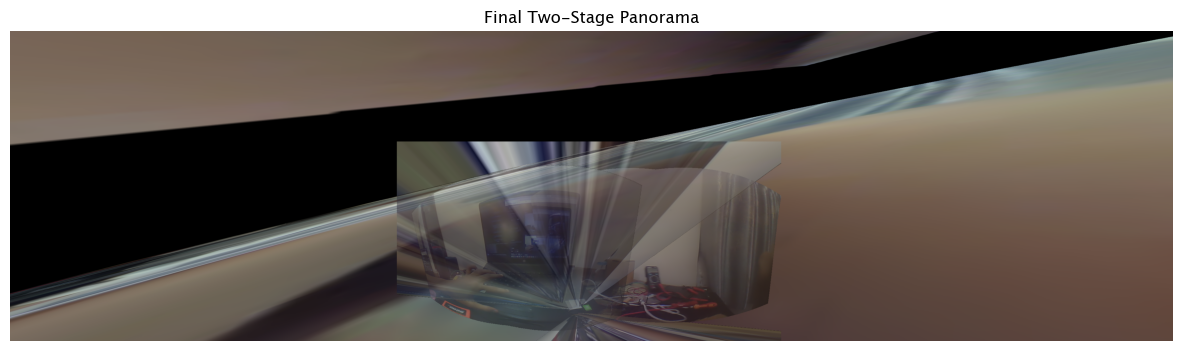


Final panorama saved: final_two_stage_panorama.jpg
Final size: 3731x996


In [12]:
def stitch_esp_panoramas_high_feature(panoramas: Dict[str, np.ndarray], high_mpix: float = 1.2) -> np.ndarray:
    """Stitch the ESP panoramas together using high feature detection"""
    print(f"\n{'='*60}")
    print(f"STAGE 2: High-feature stitching of {len(panoramas)} ESP panoramas")
    print(f"{'='*60}")
    
    if len(panoramas) == 1:
        return list(panoramas.values())[0]
    
    # Prepare images with higher resolution
    esp_ids = list(panoramas.keys())
    imgs = []
    for esp_id in esp_ids:
        img = resize_to_megapix(panoramas[esp_id], high_mpix, allow_upscale=False)
        imgs.append(img)
        print(f"ESP {esp_id}: {img.shape[1]}x{img.shape[0]}")
    
    try:
        # Use high feature count for better matching between ESP panoramas
        finder = FeatureDetector(detector=DETECTOR, nfeatures=N_FEATURES_INTER)
        matcher = FeatureMatcher(matcher_type="homography", range_width=-1)
        
        print("Detecting features (high count)...")
        features = [finder.detect_features(img) for img in imgs]
        print(f"Features detected: {[len(f.keypoints) for f in features]}")
        
        print("Matching features...")
        matches = matcher.match_features(features)
        print(f"Pairwise matches: {len([m for m in matches if m.confidence > 0.3])}")
        
        # Keep connected component
        subsetter = Subsetter(confidence_threshold=0.2)  # Lower threshold for ESP panoramas
        indices = subsetter.get_indices_to_keep(features, matches)
        
        if len(indices) != len(features):
            print(f"Keeping {len(indices)}/{len(features)} connected ESP panoramas")
            imgs = [imgs[i] for i in indices]
            features = [features[i] for i in indices]
            matches = subsetter.subset_matches(matches, indices)
            esp_ids = [esp_ids[i] for i in indices]
        
        if len(imgs) < 2:
            print("Not enough connected panoramas")
            return imgs[0] if imgs else np.zeros((480, 640, 3), dtype=np.uint8)
        
        # Try spherical stitching first
        try:
            print("Attempting spherical stitching...")
            estimator = CameraEstimator()
            cameras = estimator.estimate(features, matches)
            
            adjuster = CameraAdjuster(confidence_threshold=0.2)
            cameras = adjuster.adjust(features, matches, cameras)
            
            corrector = WaveCorrector()
            cameras = corrector.correct(cameras)
            
            warper = Warper("spherical")
            warper.set_scale(cameras)
            
            sizes = [(img.shape[1], img.shape[0]) for img in imgs]
            
            warped_imgs = list(warper.warp_images(imgs, cameras, aspect=1.0))
            warped_masks = list(warper.create_and_warp_masks(sizes, cameras, aspect=1.0))
            corners, sizes_out = warper.warp_rois(sizes, cameras, aspect=1.0)
            
            seam_finder = SeamFinder()
            seam_masks = seam_finder.find(warped_imgs, corners, warped_masks)
            
            compensator = ExposureErrorCompensator()
            compensator.feed(corners, warped_imgs, warped_masks)
            compensated_imgs = [
                compensator.apply(i, corner, img, mask)
                for i, (img, mask, corner) in enumerate(zip(warped_imgs, warped_masks, corners))
            ]
            
            blender = Blender()
            blender.prepare(corners, sizes_out)
            for img, mask, corner in zip(compensated_imgs, seam_masks, corners):
                blender.feed(img, mask, corner)
            
            result, _ = blender.blend()
            print(f"Spherical stitching successful: {result.shape[1]}x{result.shape[0]}")
            return result
            
        except Exception as e:
            print(f"Spherical stitching failed: {e}")
            print("Falling back to homography stitching...")
    
    except Exception as e:
        print(f"Feature-based stitching setup failed: {e}")
    
    # Fallback: sequential homography stitching
    print("Using sequential homography stitching...")
    result = imgs[0]
    for i in range(1, len(imgs)):
        print(f"Stitching ESP {esp_ids[0]} with ESP {esp_ids[i]}...")
        result = simple_stitch_pair(result, imgs[i], DETECTOR, N_FEATURES_INTER)
        esp_ids[0] = f"{esp_ids[0]}+{esp_ids[i]}"  # Update combined name
    
    return result

# Perform Stage 2 stitching
print("Starting Stage 2: Inter-ESP stitching...")
final_panorama = stitch_esp_panoramas_high_feature(esp_panoramas, HIGH_MPIX)

# Show final result
plot_image(final_panorama, figsize=(15, 10), title="Final Two-Stage Panorama")

# Save final result
final_output_path = "final_two_stage_panorama.jpg"
cv.imwrite(final_output_path, final_panorama)
print(f"\nFinal panorama saved: {final_output_path}")
print(f"Final size: {final_panorama.shape[1]}x{final_panorama.shape[0]}")

# Summary and comparison


In [6]:
print(f"\n{'='*80}")
print("TWO-STAGE STITCHING SUMMARY")
print(f"{'='*80}")
print(f"Stage 1 (Intra-ESP spherical stitching):")
for esp_id, panorama in esp_panoramas.items():
    h, w = panorama.shape[:2]
    print(f"  ESP {esp_id}: {len(esp_groups[esp_id])} images → {w}x{h} panorama")

print(f"\nStage 2 (Inter-ESP high-feature stitching):")
print(f"  {len(esp_panoramas)} ESP panoramas → {final_panorama.shape[1]}x{final_panorama.shape[0]} final panorama")

print(f"\nAdvantages of this approach:")
print("  • Leverages high overlap within ESP groups for robust spherical stitching")
print("  • Uses high feature detection for challenging inter-ESP matching")
print("  • More computationally efficient than processing all images together")
print("  • Better handles varying overlap patterns between different ESP devices")
print("  • Reduces accumulation of registration errors")


TWO-STAGE STITCHING SUMMARY
Stage 1 (Intra-ESP spherical stitching):
  ESP esp_1: 12 images → 813x504 panorama
  ESP esp_2: 12 images → 732x463 panorama
  ESP esp_3: 7 images → 460x352 panorama
  ESP esp_4: 11 images → 525x356 panorama

Stage 2 (Inter-ESP high-feature stitching):


NameError: name 'final_panorama' is not defined